<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Practica_23_RegresionLinealSimple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Regresión Lineal Simple con Scikit-Learn
---


## Datos del Estudiante

*   Apellidos y Nombre:
*   Matrícula:

---

## Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar la regresión lineal simple utilizando Scikit-Learn para modelar la relación entre dos variables numéricas**, verificar los principales supuestos del modelo (linealidad, normalidad de residuos y homocedasticidad), **interpretar los coeficientes del modelo**, calcular e interpretar la **correlación entre variables** y evaluar el desempeño del modelo mediante métricas como el MSE, RMSE y R².


Trabajarás con el archivo restaurantes.csv, que contiene dos columnas:

- `population`: población de la ciudad (variable independiente). Tiene valores decimales mayores que cero. Estos valores representan la población de la ciudad multiplicada por 10,000. Por ejemplo, 6.1101 significa que la población de esa ciudad es 61,101.

- `profit`: ganancia del restaurante en esa ciudad (variable dependiente). Tiene valores decimales, algunos negativos y otros positivos. Estos representan las ganancias mensuales promedio de su restaurante en cada ciudad, en unidades de $10,000. Por ejemplo, 17.592 representa 175,920 en ganancias mensuales promedio para esa ciudad. -2.6807 representa -26,807 en pérdidas mensuales promedio para esa ciudad.





## 🔧 Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `restaurantes.csv`
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente el conjunto de datos.

In [214]:
# Escribe tu código aquí
from google.colab import drive
drive.mount('/content/mydrive/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/restaurantes.csv

Drive already mounted at /content/mydrive/; to attempt to forcibly remount, call drive.mount("/content/mydrive/", force_remount=True).
--2025-11-01 04:33:03--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/restaurantes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1376 (1.3K) [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/restaurantes.csv.5’

restaurantes.csv.5  100%[===================>]   1.34K  --.-KB/s    in 0s      

2025-11-01 04:33:03 (86.3 MB/s) - ‘/content/drive/MyDrive/ClassFiles/restaurantes.csv.5’ saved [1376/1376]



In [215]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/restaurantes.csv')
df = df.rename(columns={'poblation':'population'})
df.head()

,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [216]:
df.describe()

,population,profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


##  Parte 2: Análisis exploratorio y relación entre variables

### 2.1 Diagrama de Dispersión
1. Grafica un **diagrama de dispersión** entre `poblation` y `profit`
2. Responde:  
  ¿La relación entre las variables parece lineal? ¿Por qué? <br>
  **Sí, parece lineal. El beneficio 'profit' es proporcional al incremento de población en forma ascendente (positiva).**

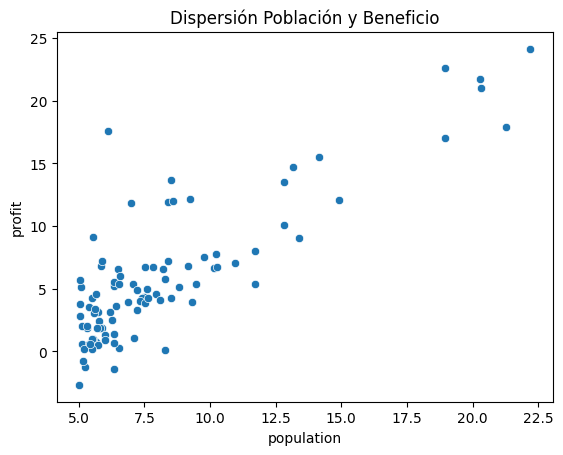

In [217]:
# Diagrama de dispersión
sns.scatterplot(df, x='population', y='profit')
plt.title('Dispersión Población y Beneficio')
plt.show()

### 2.2: Cálculo e interpretación de la correlación
1. Calcula e imprime el **coeficiente de correlación de Pearson** entre `poblation` y `profit`
2. Interpreta el resultado:


---


- ¿Qué tan fuerte es la relación? <br> **0.8378**
- ¿Es positiva o negativa? <br> **Positiva**
- ¿Es coherente con el gráfico anterior? <br> **Sí, indicando una tendencia positiva y fuerte, siendo un buen predictor de la variable 'profit'/.**

In [218]:
# Cálculo de correlación
from scipy.stats import pearsonr
result = pearsonr(x=df['population'], y=df['profit'])
print(f"Coefficiente de correlación de Pearson: {result.statistic}")

Coefficiente de correlación de Pearson: 0.8378732325263409


## Parte 3: Construcción del modelo, coeficientes y visualización

###3.1 Construcción del modelo - obtención de los parámetros y coeficientes
1. Construye un modelo de regresión lineal simple usando las bibliotecas de Scikit-Learn
2. Imprime el intercepto y el coeficiente de la regresión (pendiente)
3. Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema? <br>
**el valor promedio de la variable dependiente 'profit' es -3.89 o -38,957.80, cuando la variable independiente 'population' es igual a 0.**
4. Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema? <br>
**La pendiente representa el valor promedio de cambio en la variable dependiente por cada incremento 1.0 de la variable independiente (población), la variable dependiente o beneficio (profit) crece positivamente 1.1930.**

In [219]:
# Construcción del modelo  y Coeficientes del modelo
from sklearn import linear_model
def linear_regression_model(X, y):
  L = linear_model.LinearRegression()

  L.fit(X, y)

  print(f"coeficiente m: {L.coef_[0]} (Contexto: {L.coef_[0]*10000})")
  print(f"Intercepto b: {L.intercept_} (Contexto: {L.intercept_*10000})\n")

  y_pred = L.predict(X)

  print(f"profit = {L.intercept_} + {L.coef_[0]} * population")



  return X, y, y_pred

X = df[['population']]
y = df['profit']

X, y, y_pred = linear_regression_model(X, y)

coeficiente m: 1.1930336441895932 (Contexto: 11930.336441895932)
Intercepto b: -3.8957808783118484 (Contexto: -38957.80878311848)

profit = -3.8957808783118484 + 1.1930336441895932 * population


### 3.2 Visualización del modelo
1. Grafica los puntos originales (population vs profit) y dibuja la línea de regresión ajustada.
2. Asegúrate de incluir leyenda y títulos.

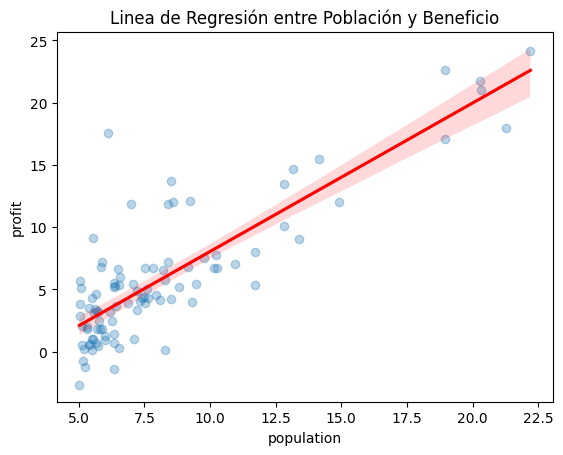

In [220]:
# Visualización del modelo ajustado
def visualization_regression_model(X, y):
  sns.regplot(x=X, y=y, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
  plt.title('Linea de Regresión entre Población y Beneficio')
  plt.show()

visualization_regression_model(X, y)

## Parte 4: Supuestos del modelo de regresión lineal

### 4.1. Normalidad de los residuos
1. Calcula los residuos (reales - predichos).
2. Grafica un **histograma con KDE** de los residuos.
3. Responde: ¿Los residuos siguen una distribución normal?<br>
  **Pareciera que los resisuos siguieran una distribución normal, aunque un dato a la derecha, causa que exista una cola larga a la derecha.**

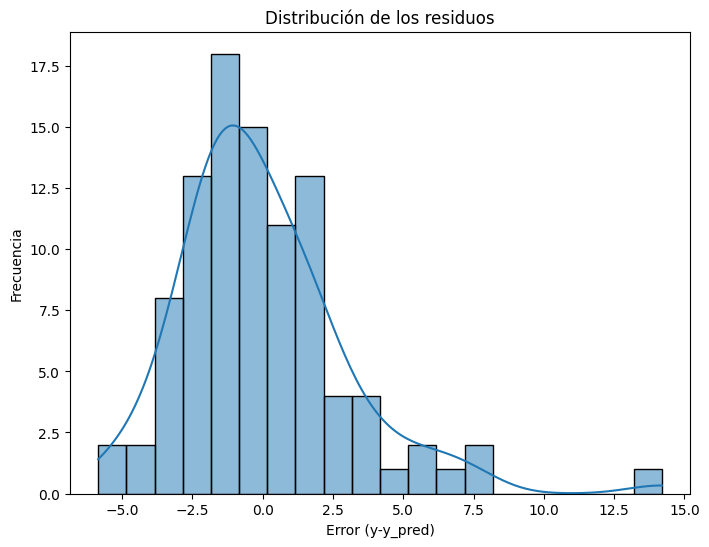

In [221]:
# Normalidad de los residuos
def residuals_normality(y, y_pred):
  residuos = y - y_pred
  # residuos = residuos.loc[residuos < 7.5]
  plt.figure(figsize=(8, 6))
  sns.histplot(residuos, bins=20, kde=True)
  plt.xlabel("Error (y-y_pred)")
  plt.ylabel("Frecuencia")
  plt.title("Distribución de los residuos")
  plt.show()

  return residuos

residuos = residuals_normality(y, y_pred)

### 4.2. Homocedasticidad
1. Grafica los residuos vs valores predichos.
2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón? <br>
  **La mayoría de los datos se concentra cerca de 0.0, aunque hay al menos 6 datos que se encuentra más alejados que los demás.**

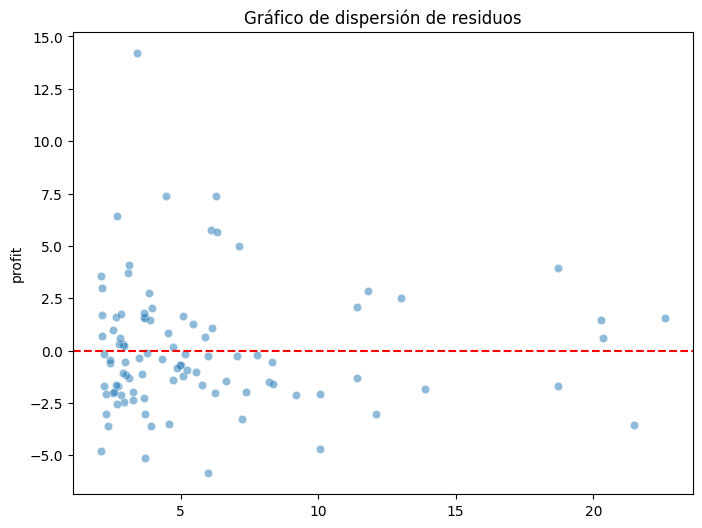

In [222]:
# Gráfico de residuos vs predichos
def homocedasticidad(residuos, y_pred):
  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=y_pred, y=residuos, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title("Gráfico de dispersión de residuos")
  plt.show()

homocedasticidad(residuos, y_pred)

### 4.3. Q-Q Plot para evaluar la normalidad
1. Grafica el Q-Q Plot:.
2. Interpreta el gráfico: <br>
    a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.<br>
      **Gráficamente, podemos observar que los puntos sobre la línea diagonal, se alinean, mostrando que estos siguen una distribución normal, aunque aun tenemos la prescencia de un dato atípico.**<br>
    b) Desviaciones sistemáticas indican asimetría o colas pesadas.

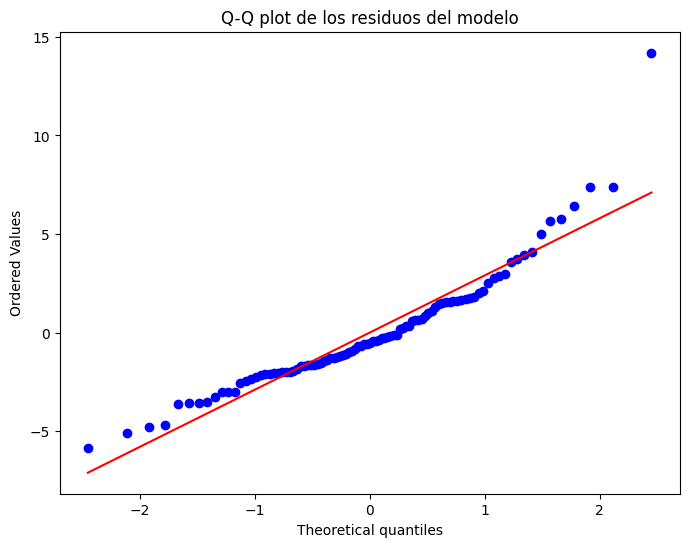

In [223]:
# Q-Q Plot
import scipy.stats as stats
def qq_plot(residuos):
  plt.figure(figsize=(8, 6))
  stats.probplot(residuos, dist='norm', plot=plt)
  plt.title('Q-Q plot de los residuos del modelo')
  plt.show()

qq_plot(residuos)

## Parte 5: Evaluación del modelo
1. Calcula las métricas:
- MSE
- RMSE
- R²
2. Interpreta: ¿Qué nos dicen sobre el ajuste del modelo?<br>
  **MSE y RMSE siendo sensibles a valores atípicos, podrían estar sesgados, RMSE para este modelo nos indica que las predicciones estan 2.99  unidades de los valores reales.**<br>
  **R2 nos indica que el modelo explica el 70.20% de la variabilidad.**

In [224]:
# Evaluación del modelo
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
def metrics(y, y_pred):
  print(f"MSE: {mean_squared_error(y, y_pred)}")
  print(f"RMSE: {root_mean_squared_error(y, y_pred)}")
  print(f"R2: {r2_score(y, y_pred)}")

metrics(y, y_pred)

MSE: 8.953942751950358
RMSE: 2.9923139460876023
R2: 0.7020315537841397


## Parte 6: Conclusiones
Responde con tus propias palabras:
- ¿Qué tan útil consideras el modelo?
- ¿Qué limitaciones encuentras?
- ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?  Si crees que es necesario hacerlo realiza el ajuste.

In [225]:
dft = df.copy()

In [230]:
from scipy.stats import boxcox
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, Normalizer

# Transformaciones
scaler = MinMaxScaler()
scaled = scaler.fit_transform(dft)
scaled_df = pd.DataFrame(scaled, columns=df.columns, index=df.index)
scaled_df

X = scaled_df[['population']]
y = scaled_df['profit']


# sns.histplot(Xt, bins=20, kde=True)

coeficiente m: 0.7638248965049139 (Contexto: 7638.248965049139)
Intercepto b: 0.17825530879146598 (Contexto: 1782.5530879146597)

profit = 0.17825530879146598 + 0.7638248965049139 * population


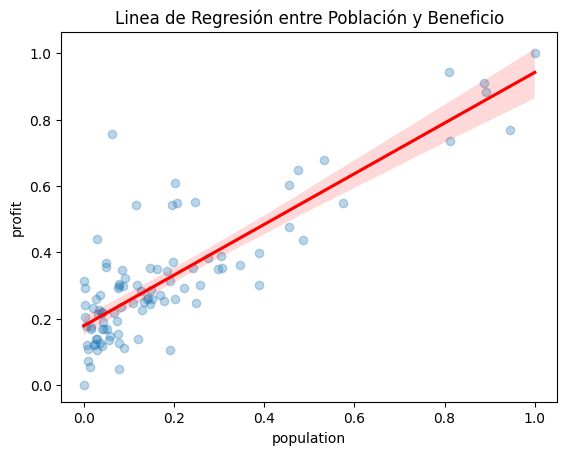

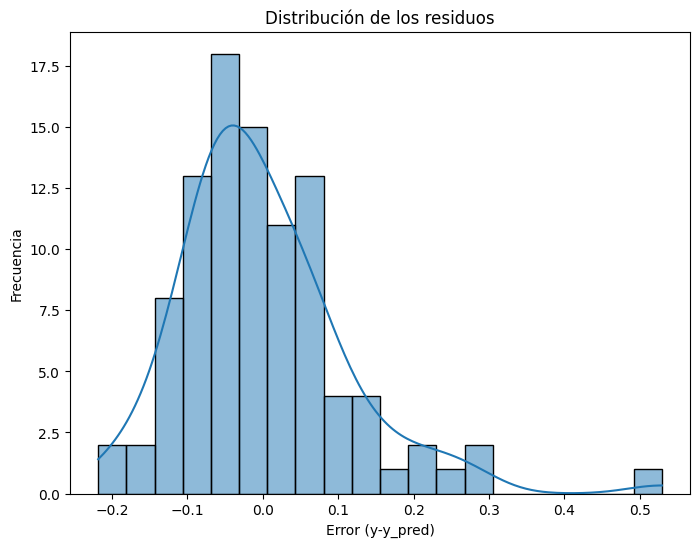

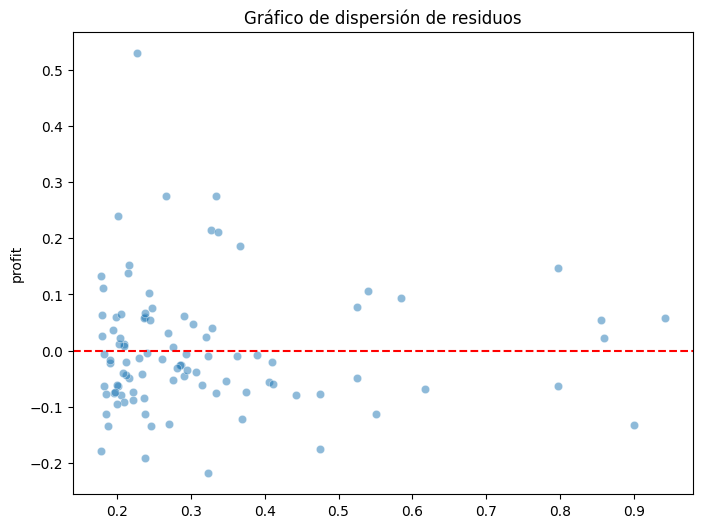

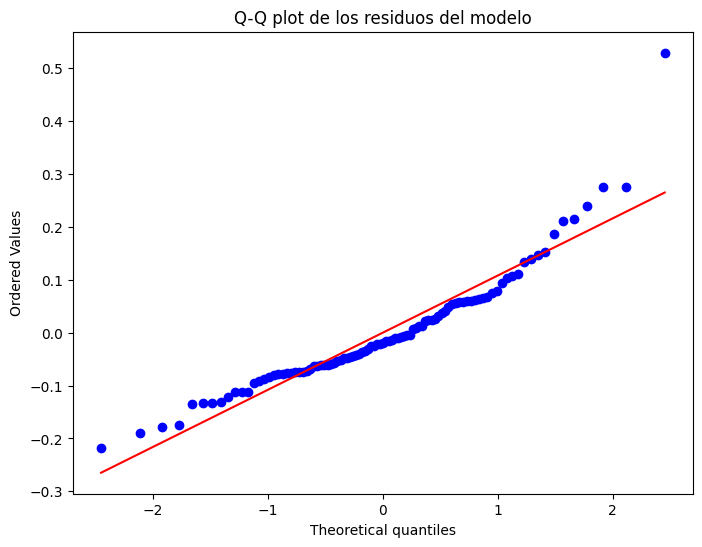

MSE: 0.012440774864962551
RMSE: 0.11153822154294263
R2: 0.7020315537841397


In [231]:
X, y, y_pred = linear_regression_model(X, y)
visualization_regression_model(X, y)
residuos = residuals_normality(y, y_pred)
homocedasticidad(residuos, y_pred)
qq_plot(residuos)
metrics(y, y_pred)

# Conclusiones de mejorar el modelo:

Utilice el MinMaxScaler para convertir la escala de los datos, esto nos ayudo a que el modelo fuera capaz de entender mejor las variables y como estas crecian, de StandardScaler, RobustScaler, MinMaxScaler fue el que mejor redujo MSE y RMSE sin afectar R2 o la variabilidad que el modelo podía catpurar sin afectar las predicciones.